In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as an
import scipy
from scipy.sparse import csr_matrix
import sklearn
import sklearn.metrics as sm
import gget
from tabulate import tabulate

import utils as ut

sc.settings.verbosity = 3  

# Load the raw data

In [2]:
fpath = "/scratch/indikar_root/indikar1/shared_data/single_cell_fibroblast/scanpy/processed.anndata.h5ad"

adata = sc.read_h5ad(fpath)
adata.obs['UMAP 1'] = adata.obsm['X_umap'][:, 0]
adata.obs['UMAP 2'] = adata.obsm['X_umap'][:, 1]

sc.logging.print_memory_usage()
adata

Memory usage: current 2.67 GB, difference +2.67 GB


AnnData object with n_obs × n_vars = 7748 × 14082
    obs: 'n_genes', 'cell', 'G1', 'G2M', 'S', 'pred_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'pred_G1', 'pred_S', 'pred_G2M', 'dpt_pseudotime', 'UMAP 1', 'UMAP 2'
    var: 'gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'seurat_S', 'seurat_G2M', 'is_seurat', 'is_kegg', 'whitfield_G1/S', 'whitfield_G2', 'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'is_whitfield', 'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S', 'is_GO', 'LIU_G2MvsG0G1', 'LIU_G2MvsS', 'LIU_SvsG0G1', 'is_LIU', 'cell_cycle', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts

# Filtering

In [3]:
adata = adata[~adata.obs['leiden'].isin(['2', '3']), :].copy()
adata

AnnData object with n_obs × n_vars = 7080 × 14082
    obs: 'n_genes', 'cell', 'G1', 'G2M', 'S', 'pred_phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden', 'pred_G1', 'pred_S', 'pred_G2M', 'dpt_pseudotime', 'UMAP 1', 'UMAP 2'
    var: 'gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'seurat_S', 'seurat_G2M', 'is_seurat', 'is_kegg', 'whitfield_G1/S', 'whitfield_G2', 'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'is_whitfield', 'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S', 'is_GO', 'LIU_G2MvsG0G1', 'LIU_G2MvsS', 'LIU_SvsG0G1', 'is_LIU', 'cell_cycle', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts

In [4]:
keep_obs = [
    'cell',
    'G1',
    'G2M',
    'S',
    'pred_phase',
    'UMAP 1',
    'UMAP 2',
    'leiden',
]

keep_var = [
    'gene_name',
    'seurat_S',
    'seurat_G2M',
    'whitfield_G1/S',
    'whitfield_G2',
    'whitfield_G2/M',
    'whitfield_M/G1',
    'whitfield_S',
    'GO_G1',
    'GO_G1/S', 
    'GO_G2',
    'GO_G2/M',
    'GO_M', 
    'GO_S',
]

cell_cycle = keep_var[1:]

# drop unneed obs columns
for column in adata.obs.columns:
    if not column in keep_obs:
        del adata.obs[column]

# drop unneed var columns
for column in adata.var.columns:
    if not column in keep_var:
        del adata.var[column]

    # convert to boolean
    if column in cell_cycle:
        adata.var[column] = adata.var[column] == 'True'

adata

AnnData object with n_obs × n_vars = 7080 × 14082
    obs: 'cell', 'G1', 'G2M', 'S', 'pred_phase', 'leiden', 'UMAP 1', 'UMAP 2'
    var: 'gene_name', 'seurat_S', 'seurat_G2M', 'whitfield_G1/S', 'whitfield_G2', 'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S'
    uns: 'diffmap_evals', 'hvg', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'pred_phase_colors', 'rank_genes_groups', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log_norm', 'norm'
    obsp: 'connectivities', 'distances'

,cell,G1,G2M,S,pred_phase,leiden,UMAP 1,UMAP 2
cell_id,,,,,,,,
AAACCAAAGGGTAGCA,AAACCAAAGGGTAGCA,80.0,403.0,87.0,G2M,0,6.556191,12.091688
AAACCAAAGTAAGGGT,AAACCAAAGTAAGGGT,18.0,5.0,7.0,G1,1,1.604253,0.465417
AAACCATTCAGGTAGG,AAACCATTCAGGTAGG,43.0,183.0,59.0,G2M,0,5.898338,9.881801
AAACCATTCCAGCCCT,AAACCATTCCAGCCCT,229.0,43.0,1872.0,S,1,4.042889,1.645078
AAACCATTCGTGACCG,AAACCATTCGTGACCG,58.0,1.0,2.0,G1,1,0.409459,1.036309


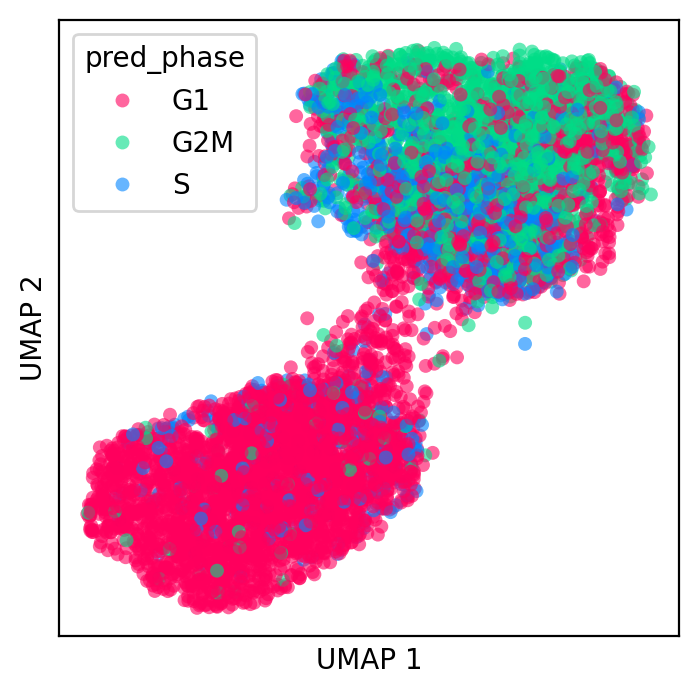

In [5]:
pdf = adata.obs.copy()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    data=pdf,
    x='UMAP 1',
    y='UMAP 2',
    ec='none',
    alpha=0.6,
    hue='pred_phase',
    s=25,
    palette=["#FF005D", "#00DD87", "#0085FF"],
)

plt.yticks([])
plt.xticks([])

pdf.head()

computing PCA
    with n_comps=50
    finished (0:00:11)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:15)


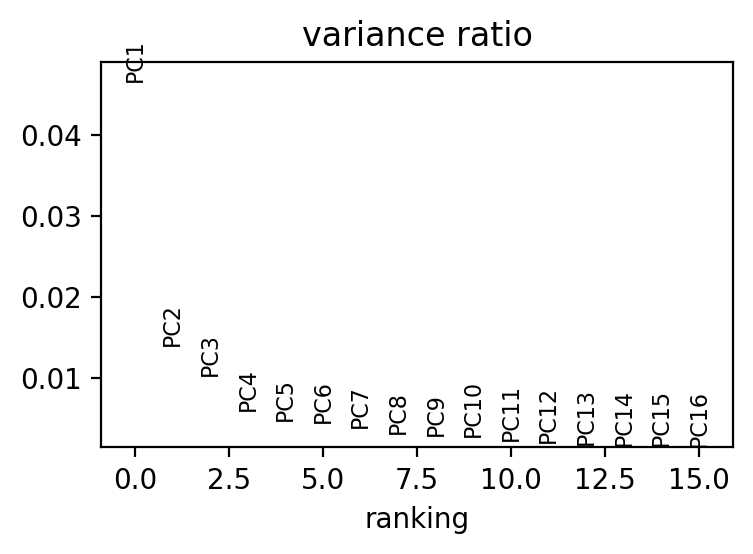

In [6]:
"""
recompute the PCA embeddings on all genes
"""
sc.pp.pca(
    adata,
    mask_var=None,
    layer='log_norm',
)

sc.pp.neighbors(
    adata,
    n_neighbors=5,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 2.5
sc.pl.pca_variance_ratio(adata, n_pcs=15)

# Simple annotations

In [7]:
sc.pp.calculate_qc_metrics(adata)
sc.pp.highly_variable_genes(adata)
adata

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


AnnData object with n_obs × n_vars = 7080 × 14082
    obs: 'cell', 'G1', 'G2M', 'S', 'pred_phase', 'leiden', 'UMAP 1', 'UMAP 2'
    var: 'gene_name', 'seurat_S', 'seurat_G2M', 'whitfield_G1/S', 'whitfield_G2', 'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'diffmap_evals', 'hvg', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'pred_phase_colors', 'rank_genes_groups', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log_norm', 'norm'
    obsp: 'connectivities', 'distances'

# Compute silhouette_score of predicted labels

In [8]:
"""
silhouette_score of predicted phase assignment using 5 knn graph built on PCA embeddings
"""

X = adata.obsp['distances'].copy()
labels = adata.obs['pred_phase'].values

score = sm.silhouette_score(
    X, labels,
    metric='precomputed'
)

print(score) # grim

-0.7882881881906413


In [9]:
adata

AnnData object with n_obs × n_vars = 7080 × 14082
    obs: 'cell', 'G1', 'G2M', 'S', 'pred_phase', 'leiden', 'UMAP 1', 'UMAP 2'
    var: 'gene_name', 'seurat_S', 'seurat_G2M', 'whitfield_G1/S', 'whitfield_G2', 'whitfield_G2/M', 'whitfield_M/G1', 'whitfield_S', 'GO_G1', 'GO_G1/S', 'GO_G2', 'GO_G2/M', 'GO_M', 'GO_S', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'diffmap_evals', 'hvg', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'pred_phase_colors', 'rank_genes_groups', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log_norm', 'norm'
    obsp: 'connectivities', 'distances'

In [10]:
var = adata.var.copy()

# filter out lowly expressed genes 
percent_threshold = 10
var['percent_cells'] = (adata.X.astype(bool).sum(axis=0) / len(adata)) * 100
var = var[var['percent_cells'] > percent_threshold]
var = var.sort_values(by='percent_cells', ascending=False)

# filter out non cell cycle genes
mask = var[cell_cycle].any(axis=1)
var = var[mask]

print(f"{var.shape=}")
var.head()

var.shape=(81, 19)


,gene_name,seurat_S,seurat_G2M,whitfield_G1/S,whitfield_G2,whitfield_G2/M,whitfield_M/G1,whitfield_S,GO_G1,GO_G1/S,GO_G2,GO_G2/M,GO_M,GO_S,highly_variable,means,dispersions,dispersions_norm,percent_cells
APP,APP,False,False,False,False,False,False,False,False,False,False,True,False,False,False,2.663175,0.528767,-0.994023,99.901130
CDKN1A,CDKN1A,False,False,False,False,False,False,False,False,True,False,False,False,False,False,1.935490,0.229586,-0.626395,99.053672
PRIM1,PRIM1,True,False,False,False,False,False,False,False,False,False,False,False,False,True,2.255471,1.535525,1.044523,98.827684
CKS2,CKS2,False,True,False,False,True,False,False,False,False,False,False,False,False,False,1.718731,0.125885,-0.845444,97.951977
GMNN,GMNN,True,False,False,False,False,False,False,False,False,False,False,False,False,False,1.498321,0.215022,-0.484567,94.322034


In [11]:
# find out how these genes are distributed across the 
# intial predicted phases

aggdata = sc.get.aggregate(
    adata,
    by='pred_phase',
    func='mean',
)

df = aggdata.to_df(layer='mean').T

markers = df.loc[var['gene_name'].values]
markers = markers.loc[markers.std(axis=1).sort_values(ascending=False).index]
markers = markers.idxmax(axis=1).reset_index()
markers.columns = ['gene_name', 'phase']

n = 5
markers = markers.groupby('phase').head(n).reset_index(drop=True)
markers = markers.sort_values('phase')
markers

,gene_name,phase
2,PRIM1,G1
5,MCM7,G1
7,CUL1,G1
8,CUL2,G1
11,EXO1,G1
0,CDK6,G2M
1,GAS2L3,G2M
3,GMNN,G2M
4,CCND1,G2M
6,ENSA,G2M


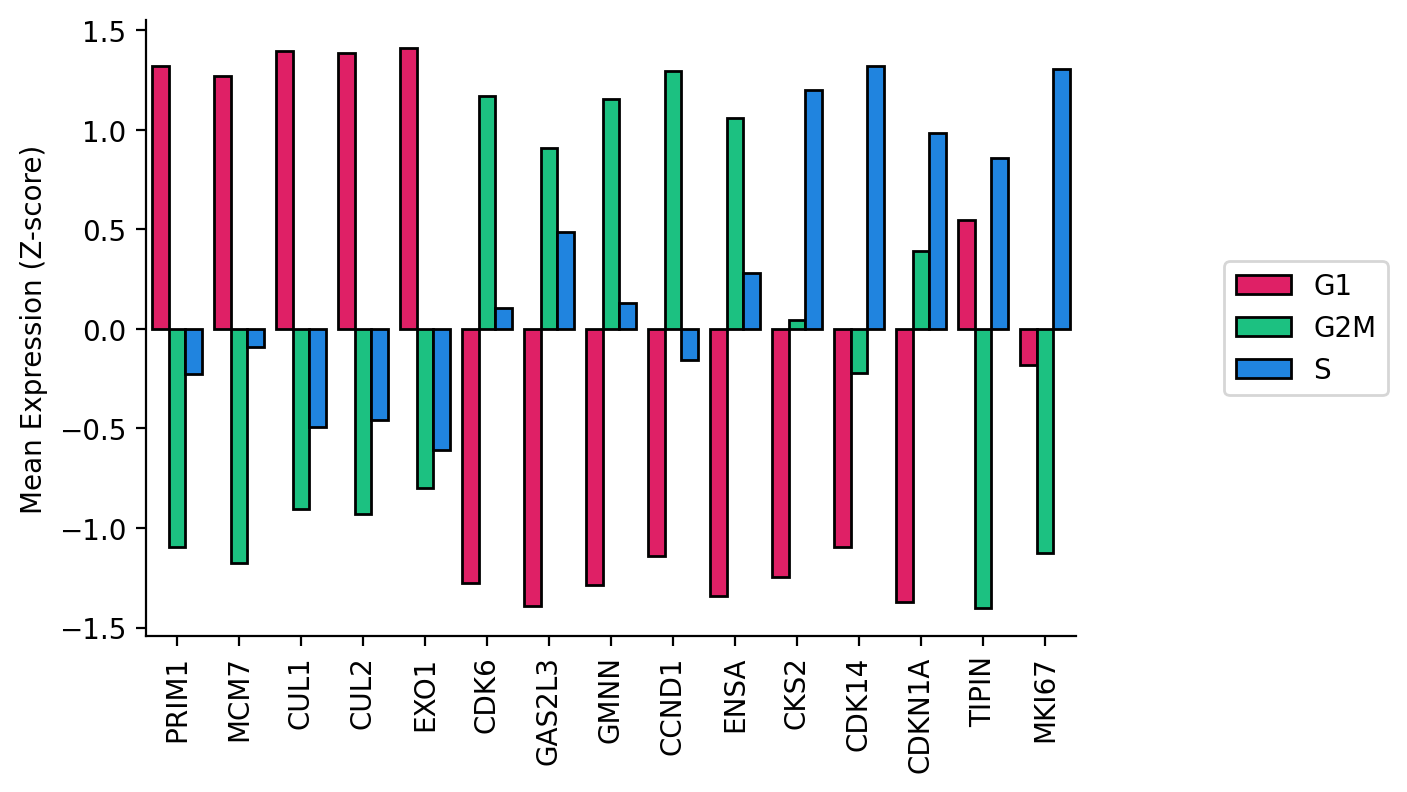

In [12]:
pdf = df.copy()
pdf = pdf.loc[markers['gene_name'].values]
pdf = pdf.apply(scipy.stats.zscore, axis=1)
pdf = pdf.reset_index()
pdf = pd.melt(pdf, id_vars='index')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 4

sns.barplot(
    data=pdf,
    x='index',
    y='value',
    hue='variable',
    ec='k',
    palette=["#FF005D", "#00DD87", "#0085FF"],
)

plt.gca().tick_params(axis='x', rotation=90)
plt.ylabel('Mean Expression (Z-score)')
plt.xlabel('')

sns.move_legend(
    plt.gca(),
    loc='center right',
    bbox_to_anchor=(1.35, 0.5),
    title=''
)
sns.despine()

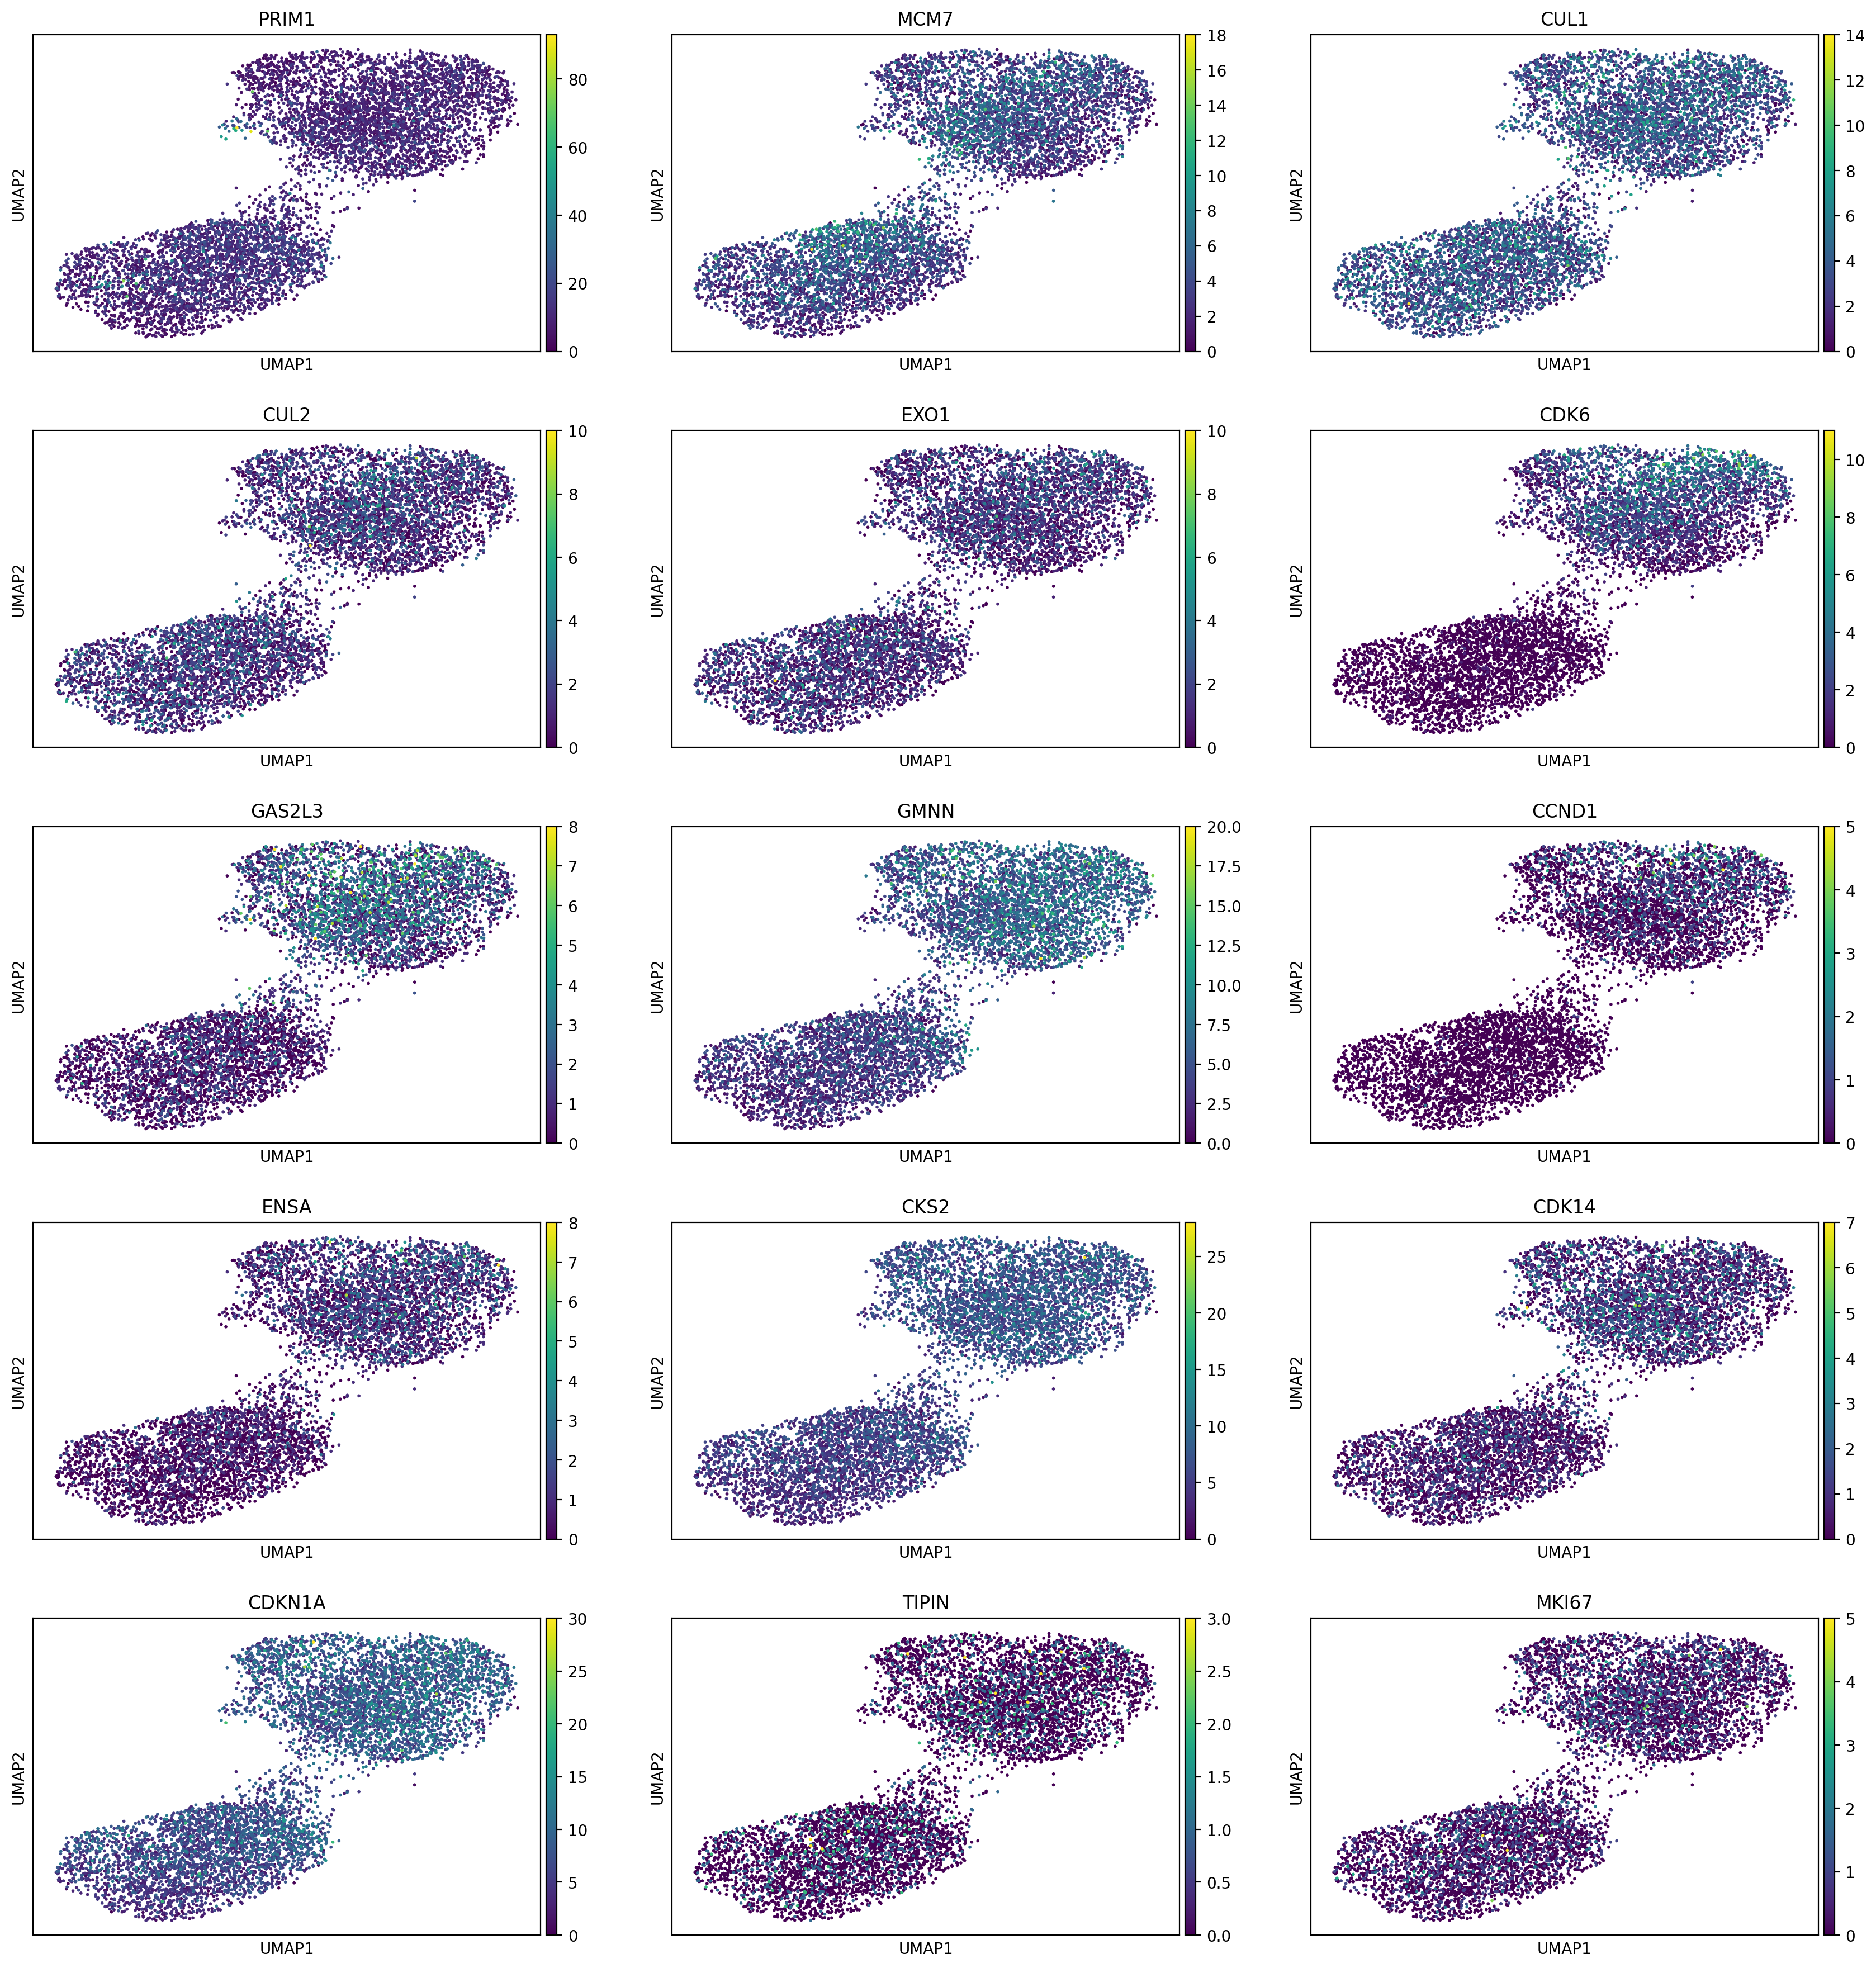

In [13]:
sc.pl.umap(
    adata,
    color=markers['gene_name'].to_list(),
    layer='counts',
    ncols=3,
)

In [14]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
df.mean(axis=0)

In [ ]:
break

In [ ]:
break

In [ ]:
aggdata = sc.get.aggregate(
    adata,
    by='pred_phase',
    func='count_nonzero',
)

aggdata.X = aggdata.layers['count_nonzero']
df = aggdata.to_df().T
df.head()

In [ ]:
break

# Find highly expression cell cycle genes

In [ ]:
fpath = "../resources/GO_Biological_Process_2023.txt"
features = ut.load_pathway(fpath)
print(f"{features.shape=}")

pathways = [
    'Regulation Of G1/S Transition Of Mitotic Cell Cycle (GO:2000045)',
    'Regulation Of G2/M Transition Of Mitotic Cell Cycle (GO:0010389)',
    'Regulation Of Cell Cycle (GO:0051726)',
    'Regulation Of Cell Cycle G1/S Phase Transition (GO:1902806)',
    'Regulation Of Cell Cycle G2/M Phase Transition (GO:1902749)',
    'Regulation Of Cell Cycle Checkpoint (GO:1901976)',
    'Regulation Of Cell Cycle Phase Transition (GO:1901987)',
    'Regulation Of Cell Cycle Process (GO:0010564)',
    'Regulation Of Meiotic Cell Cycle (GO:0051445)',
    'Regulation Of Metaphase/Anaphase Transition Of Cell Cycle (GO:1902099)',
    'Regulation Of Mitotic Cell Cycle (GO:0007346)',
    'Regulation Of Mitotic Cell Cycle Phase Transition (GO:1901990)',
    'Regulation Of Mitotic Cell Cycle Spindle Assembly Checkpoint (GO:0090266)',
    'Regulation Of Nuclear Cell Cycle DNA Replication (GO:0033262)',
    'Regulation Of Transcription Involved In G1/S Transition Of Mitotic Cell Cycle (GO:0000083)'
]

features = features[pathways]
features = features[features.any(axis=1)]
features = features[features.index.isin(adata.var_names)]
print(f"{features.shape=}")
features.head()

In [ ]:
aggdata = sc.get.aggregate(
    adata,
    by='pred_phase',
    func='count_nonzero',
)

aggdata.X = aggdata.layers['count_nonzero']
df = aggdata.to_df().T
df['total'] = df.sum(axis=1)
df['std'] = df.std(axis=1)
df.head()

In [ ]:
# print most highly expressed genes per pathway
n_genes = 2

for pathway in features:
    gene_list = features[features[pathway]].index

    exp_df = df.loc[gene_list]
    exp_df = exp_df.sort_values(by='total', ascending=False)

    print(f"\n-------- {pathway}: {len(gene_list)} genes --------")

    print(tabulate(
        exp_df.head(n_genes), 
        headers='keys', 
        tablefmt='simple'),
         )

In [ ]:
break

In [ ]:
sc.pl.umap(
    adata, 
    color=['pred_phase']
)

In [ ]:
break

In [ ]:
sc.pl.umap(
    adata, 
    color=['pred_phase', 'leiden']
)

# filtering

In [ ]:
# filtering
adata = adata[~adata.obs['leiden'].isin(['2', '3']), :].copy()
adata

In [ ]:
adata

# find the best cycle markers

In [ ]:
aggdata = sc.get.aggregate(
    adata,
    by='pred_phase',
    func='mean',
    layer='log_norm',
)

df = aggdata.to_df(layer='mean').T
print(f"{df.shape=}")
df.head()